In [4]:
!pip install numpy==1.26.4
!pip install matplotlib
!pip install scikit-learn
!pip install pillow
!pip install tensorflow==2.16.1
!pip install setuptools

import tensorflow as tf
print(tf.sysconfig.get_build_info())


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


OrderedDict({'is_cuda_build': False, 'is_rocm_build': False, 'is_tensorrt_build': False, 'msvcp_dll_names': 'msvcp140.dll,msvcp140_1.dll'})



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.16.1
GPUs: []


In [3]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

In [4]:
import tensorflow as tf

if tf.config.list_physical_devices('GPU'):
    print("GPU ready to use")
    print("Device:", tf.config.list_physical_devices('GPU')[0])
else:
    print("GPU not available, using CPU instead")

GPU not available, using CPU instead


In [2]:
import os

PROJECT_DIR = os.getcwd()
DATA_DIR = os.path.join(PROJECT_DIR, "data/cnn_dataset")
LOG_DIR = os.path.join(PROJECT_DIR, "logs")
MODELS_PATH = os.path.join(PROJECT_DIR, "models")

os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

print("Current catalog:", PROJECT_DIR)
print("Data catalog:", DATA_DIR)
print("Logs catalog:", LOG_DIR)
print("Models catalog:", MODELS_PATH)

Current catalog: G:\Kuba\JupyterProject
Data catalog: G:\Kuba\JupyterProject\data/cnn_dataset
Logs catalog: G:\Kuba\JupyterProject\logs
Models catalog: G:\Kuba\JupyterProject\models


In [11]:
import os
import json
import numpy as np
from PIL import Image
import tensorflow as tf

CATEGORY_MAP_PATH = os.path.join(DATA_DIR, "categories.json")

with open(CATEGORY_MAP_PATH, "r") as f:
    TYPE_TO_CATEGORY = json.load(f)

CATEGORIES = sorted(set(TYPE_TO_CATEGORY.values()))
CATEGORY_TO_IDX = {cat: idx for idx, cat in enumerate(CATEGORIES)}
IDX_TO_CATEGORY = {idx: cat for cat, idx in CATEGORY_TO_IDX.items()}

print(f"Categories ({len(CATEGORIES)}): {CATEGORIES}")

class CarlaDataset(tf.keras.utils.Sequence):
    def __init__(self, split_dir, img_size=(224, 224), batch_size=32, augment=False, shuffle=True):
        self.img_size = img_size
        self.batch_size = batch_size
        self.augment = augment
        self.shuffle = shuffle

        all_jsons = []
        for root, dirs, files in os.walk(split_dir):
            for f in files:
                if f.endswith(".json"):
                    all_jsons.append(os.path.join(root, f))

        self.samples = []
        skipped = 0
        for json_path in all_jsons:
            img_path = json_path.replace(".json", ".jpg")
            if not os.path.exists(img_path):
                skipped += 1
                continue
            with open(json_path, "r") as f:
                meta = json.load(f)
            type_id = meta.get("type_id", "")
            if type_id not in TYPE_TO_CATEGORY:
                skipped += 1
                continue
            category = TYPE_TO_CATEGORY[type_id]
            label_idx = CATEGORY_TO_IDX[category]
            self.samples.append({
                "img_path": img_path,
                "json_path": json_path,
                "label_idx": label_idx,
                "metadata": meta,
            })

        print(f"Loaded: {len(self.samples)} samples from '{split_dir}' (skipped: {skipped})")

        from collections import Counter
        dist = Counter(TYPE_TO_CATEGORY[s["metadata"]["type_id"]] for s in self.samples)
        for cat, cnt in sorted(dist.items()):
            print(f"    {cat}: {cnt}")

        self.num_classes = len(CATEGORIES)
        self.indices = np.arange(len(self.samples))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return max(1, len(self.samples) // self.batch_size)

    def __getitem__(self, batch_idx):
        batch_indices = self.indices[batch_idx * self.batch_size:(batch_idx + 1) * self.batch_size]
        imgs, class_labels, k_labels = [], [], []

        for i in batch_indices:
            sample = self.samples[i]

            img = Image.open(sample["img_path"]).convert("RGB")
            img = img.resize(self.img_size)
            img_arr = np.array(img, dtype=np.float32) / 255.0

            k = sample["metadata"].get("physics_label", {}).get("k", None)
            if k is None:
                continue

            if self.augment:
                if np.random.rand() > 0.5:
                    img_arr = np.fliplr(img_arr)
                angle = np.random.uniform(-20, 20)
                from PIL import Image as PILImage
                img_pil = PILImage.fromarray((img_arr * 255).astype(np.uint8))
                img_pil = img_pil.rotate(angle)
                img_arr = np.array(img_pil, dtype=np.float32) / 255.0
                zoom = np.random.uniform(0.8, 1.2)
                h, w = self.img_size
                zh, zw = int(h / zoom), int(w / zoom)
                top = (h - zh) // 2
                left = (w - zw) // 2
                img_pil2 = PILImage.fromarray((img_arr * 255).astype(np.uint8))
                img_pil2 = img_pil2.crop((left, top, left + zw, top + zh)).resize((w, h))
                img_arr = np.array(img_pil2, dtype=np.float32) / 255.0

            imgs.append(img_arr)

            label = np.zeros(self.num_classes, dtype=np.float32)
            label[sample["label_idx"]] = 1.0

            class_labels.append(label)
            k_labels.append([k])

        return np.array(imgs), {
            "class_output": np.array(class_labels),
            "k_output": np.array(k_labels)
        }

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    def get_metadata(self, global_idx):
        return self.samples[global_idx]["metadata"]

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

print("\n── TRAIN ──")
train_data = CarlaDataset(os.path.join(DATA_DIR, "train"),    img_size=IMG_SIZE, batch_size=BATCH_SIZE, augment=True,  shuffle=True)
print("\n── VALIDATION ──")
val_data   = CarlaDataset(os.path.join(DATA_DIR, "val"),      img_size=IMG_SIZE, batch_size=BATCH_SIZE, augment=False, shuffle=False)
print("\n── TEST ──")
test_data  = CarlaDataset(os.path.join(DATA_DIR, "test"),     img_size=IMG_SIZE, batch_size=BATCH_SIZE, augment=False, shuffle=False)

print(f"\nNumber of classes: {train_data.num_classes}")
print(f"Classes: {IDX_TO_CATEGORY}")

Categories (6): ['coupe', 'hatchback', 'sedan', 'suv', 'truck', 'van']

── TRAIN ──
Loaded: 13093 samples from 'G:\Kuba\JupyterProject\data/cnn_dataset\train' (skipped: 0)
    coupe: 1537
    hatchback: 2871
    sedan: 3376
    suv: 1525
    truck: 1642
    van: 2142

── VALIDATION ──
Loaded: 2809 samples from 'G:\Kuba\JupyterProject\data/cnn_dataset\val' (skipped: 0)
    coupe: 311
    hatchback: 615
    sedan: 735
    suv: 304
    truck: 395
    van: 449

── TEST ──
Loaded: 2818 samples from 'G:\Kuba\JupyterProject\data/cnn_dataset\test' (skipped: 0)
    coupe: 312
    hatchback: 594
    sedan: 689
    suv: 331
    truck: 363
    van: 529

Number of classes: 6
Classes: {0: 'coupe', 1: 'hatchback', 2: 'sedan', 3: 'suv', 4: 'truck', 5: 'van'}


In [11]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import os

IMG_SIZE = (128,128)
BATCH_SIZE = 32

In [12]:
"""
This cell is responsible for training the CNN
"""
inputs = tf.keras.Input(shape=(128,128,3))

x = layers.Conv2D(32,(3,3),activation='relu')(inputs)
x = layers.MaxPooling2D()(x)
x = layers.Conv2D(64,(3,3),activation='relu')(x)
x = layers.MaxPooling2D()(x)
x = layers.Conv2D(128,(3,3),activation='relu')(x)
x = layers.MaxPooling2D()(x)
x = layers.Flatten()(x)
x = layers.Dense(256,activation='relu')(x)
x = layers.Dropout(0.3)(x)

class_output = layers.Dense(train_data.num_classes, activation='softmax', name="class_output")(x)
k_output = layers.Dense(1, activation='linear', name="k_output")(x)

model = tf.keras.Model(inputs=inputs, outputs=[class_output, k_output])

loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
model.compile(
    optimizer='adam',
    loss={
        "class_output": tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        "k_output": "mse"
    },
    metrics={
        "class_output": "accuracy",
        "k_output": "mae"
    },
    loss_weights={
        "class_output": 1.0,
        "k_output": 0.5
    }
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 126, 126,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 63, 63,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 61, 61,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 30, 30,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 28, 28,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 14, 14,    │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 25088)     │          0 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │  6,422,784 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class_output        │ (None, 6)         │      1,542 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ k_output (Dense)    │ (None, 1)         │        257 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,517,831 (24.86 MB)

 Trainable params: 6,517,831 (24.86 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
)

G:\Kuba\JupyterProject\.venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
409/409 ━━━━━━━━━━━━━━━━━━━━ 112s 270ms/step - class_output_accuracy: 0.3070 - class_output_loss: 1.6952 - k_output_loss: 0.0392 - k_output_mae: 0.0744 - loss: 1.7148 - val_class_output_accuracy: 0.5022 - val_class_output_loss: 1.4046 - val_k_output_loss: 0.0102 - val_k_output_mae: 0.0600 - val_loss: 1.4097
Epoch 2/20
409/409 ━━━━━━━━━━━━━━━━━━━━ 49s 119ms/step - class_output_accuracy: 0.6101 - class_output_loss: 1.2299 - k_output_loss: 0.0141 - k_output_mae: 0.0861 - loss: 1.2369 - val_class_output_accuracy: 0.7669 - val_class_output_loss: 0.9865 - val_k_output_loss: 0.0033 - val_k_output_mae: 0.0429 - val_loss: 0.9882
Epoch 3/20
409/409 ━━━━━━━━━━━━━━━━━━━━ 53s 129ms/step - class_output_accuracy: 0.7562 - class_output_loss: 0.9855 - k_output_loss: 0.0074 - k_output_mae: 0.0609 - loss: 0.9892 - val_class_output_accuracy: 0.8922 - val_class_output_loss: 0.7479 - val_k_output_loss: 0.0019 - val_k_output_mae: 0.0322 - val_loss: 0.7488
Epoch 4/20
409/409 ━━━━━━━━━━━━━━━━━━━━ 61

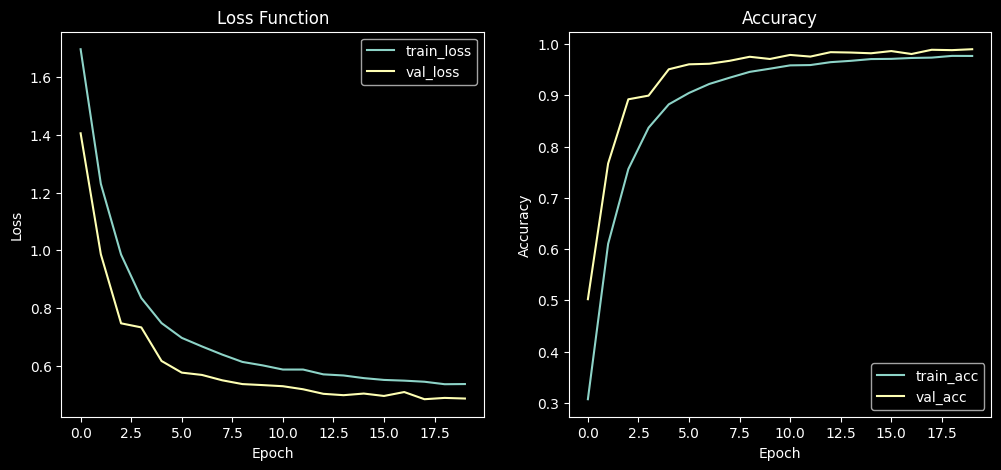

In [14]:
# Loss
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['class_output_loss'], label='train_loss')
plt.plot(history.history['val_class_output_loss'], label='val_loss')
plt.title("Loss Function")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['class_output_accuracy'], label='train_acc')
plt.plot(history.history['val_class_output_accuracy'], label='val_acc')
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

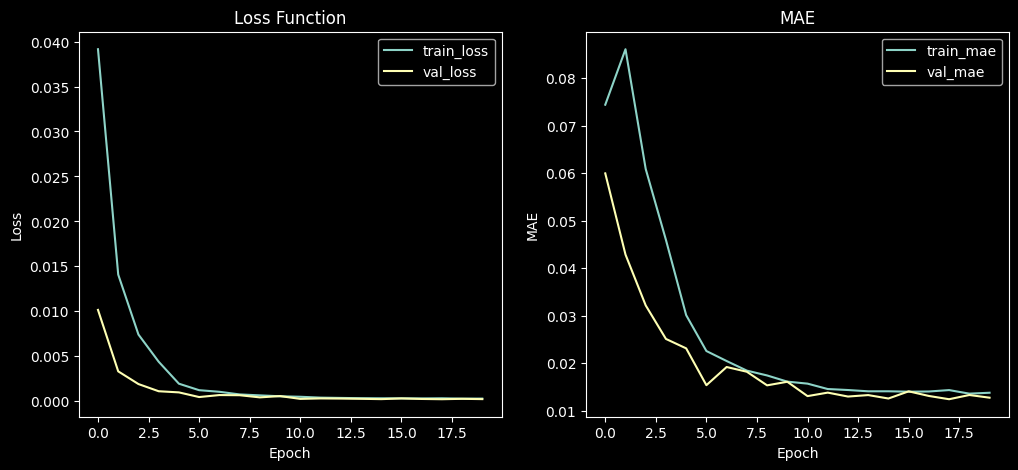

In [18]:
# Loss
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['k_output_loss'], label='train_loss')
plt.plot(history.history['val_k_output_loss'], label='val_loss')
plt.title("Loss Function")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['k_output_mae'], label='train_mae')
plt.plot(history.history['val_k_output_mae'], label='val_mae')
plt.title("MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.show()

88/88 ━━━━━━━━━━━━━━━━━━━━ 17s 191ms/step

Classification Report:
              precision    recall  f1-score   support

       coupe       1.00      0.99      0.99       312
   hatchback       0.99      0.99      0.99       594
       sedan       0.99      0.99      0.99       689
         suv       0.99      0.99      0.99       331
       truck       0.98      0.99      0.99       363
         van       1.00      0.99      0.99       527

    accuracy                           0.99      2816
   macro avg       0.99      0.99      0.99      2816
weighted avg       0.99      0.99      0.99      2816



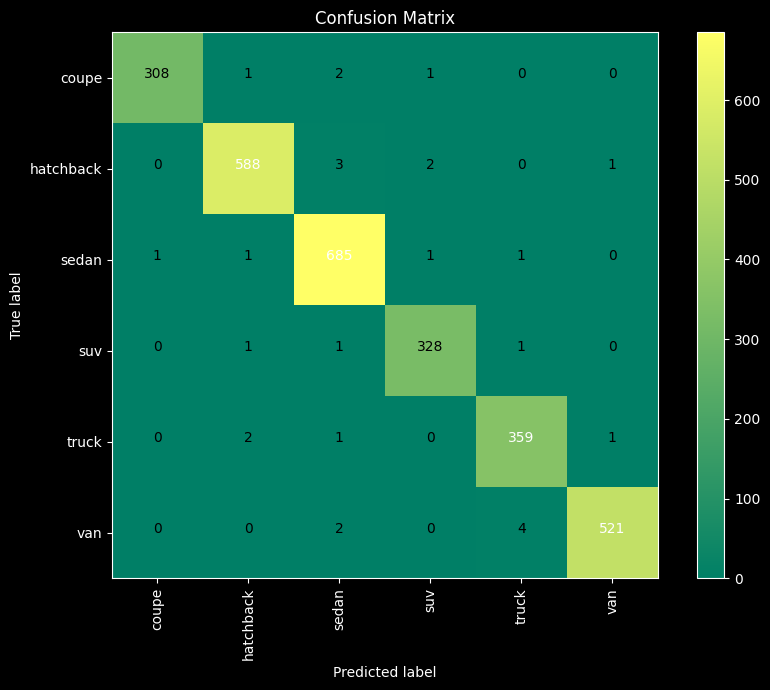

In [19]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt

# Predictions
class_pred, k_pred = model.predict(test_data)
class_pred_classes = np.argmax(class_pred, axis=1)
class_true = [s["label_idx"] for s in test_data.samples[:len(class_pred_classes)]]

# Confusion matrix
cm = confusion_matrix(class_true, class_pred_classes)

# Classification report
print("\nClassification Report:")
print(classification_report(
    class_true,
    class_pred_classes,
    target_names=CATEGORIES
))

classes = CATEGORIES

plt.figure(figsize=(9, 7))
plt.imshow(cm, cmap='summer')
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=90)
plt.yticks(tick_marks, classes)

threshold = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, cm[i, j],
            ha="center",
            color="white" if cm[i, j] > threshold else "black"
        )

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

In [20]:
try:
    MODEL_PATH = os.path.join(MODELS_PATH, "carla_classification_cnn_model_v01.h5")
    model.save(MODEL_PATH)
    print(f"Model succesfully saved in: {MODEL_PATH}")
except Exception as e:
    print(f"Model saving failed: {e}")

Model succesfully saved in: G:\Kuba\JupyterProject\models\carla_classification_cnn_model_v01.h5


In [7]:
from keras import models
model = models.load_model(
    "models/carla_classification_cnn_model_v01.h5",
    compile=False
)

In [8]:
!pip install opencv-python

  Using cached numpy-2.4.4-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
Using cached numpy-2.4.4-cp312-cp312-win_amd64.whl (12.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-intel 2.16.1 requires numpy<2.0.0,>=1.26.0; python_version >= "3.12", but you have numpy 2.4.4 which is incompatible.

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import cv2
import os
from PIL import Image
import numpy as np

VIDEO_PATH = os.path.join(PROJECT_DIR, "rgb.mp4")
OUTPUT_PATH = os.path.join(PROJECT_DIR, "output.mp4")
IMG_SIZE = (128,128)
BATCH_SIZE = 32

CATEGORY_COLORS = {
    'coupe':      (255, 100,   0),
    'hatchback':  (  0, 255, 100),
    'sedan':      (  0, 100, 255),
    'suv':        (255,   0, 200),
    'truck':      (  0, 200, 255),
    'van':        (200, 255,   0),
    'motorcycle': (255, 255,   0),
}

CONFIDENCE_THRESHOLD = 0.5
MIN_AREA = 2000

def detect_vehicles_mog2(frame, bg_subtractor):

    fg_mask = bg_subtractor.apply(frame)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    fg_mask = cv2.morphologyEx(fg_mask, cv2.MORPH_OPEN,  kernel, iterations=2)
    fg_mask = cv2.morphologyEx(fg_mask, cv2.MORPH_CLOSE, kernel, iterations=3)
    fg_mask = cv2.dilate(fg_mask, kernel, iterations=2)

    contours, _ = cv2.findContours(fg_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    candidates = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < MIN_AREA:
            continue
        x, y, w, h = cv2.boundingRect(cnt)
        aspect = w / max(h, 1)
        if 0.3 < aspect < 2.0:
            candidates.append((x, y, w, h))

    return candidates

def classify_patch(patch_bgr, model):
    img = cv2.cvtColor(patch_bgr, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)
    img_arr = np.array(img, dtype=np.float32) / 255.0
    img_batch = np.expand_dims(img_arr, axis=0)

    class_probs, k_pred = model.predict(img_batch, verbose=0)

    class_probs = class_probs[0]
    k_pred = float(k_pred[0][0])

    pred_idx = int(np.argmax(class_probs))
    confidence = float(class_probs[pred_idx])
    category = IDX_TO_CATEGORY[pred_idx]

    return category, confidence, class_probs, k_pred

def draw_bbox(frame, x, y, w, h, category, confidence, probs):
    color = CATEGORY_COLORS.get(category, (255, 255, 255))

    cv2.rectangle(frame, (x, y), (x + w, y + h), color, 2)

    label = f"{category} {confidence*100:.1f}% | k={k_pred:.3f}"
    (lw, lh), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
    cv2.rectangle(frame, (x, y - lh - 10), (x + lw + 6, y), color, -1)

    cv2.putText(frame, label, (x + 3, y - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2)

    bar_w = int(w * confidence)
    cv2.rectangle(frame, (x, y + h + 2), (x + bar_w, y + h + 8), color, -1)
    cv2.rectangle(frame, (x, y + h + 2), (x + w,     y + h + 8), color,  1)

    sorted_probs = sorted(enumerate(probs), key=lambda x: -x[1])[:3]
    for rank, (idx, prob) in enumerate(sorted_probs):
        cat_name = IDX_TO_CATEGORY[idx]
        txt = f"{cat_name}: {prob*100:.1f}%"
        cv2.putText(frame, txt, (x + w + 5, y + 15 + rank * 18),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1)

cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise FileNotFoundError(f"Can't open file: {VIDEO_PATH}")

fps    = cap.get(cv2.CAP_PROP_FPS)
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print(f"Video: {width}x{height} @ {fps:.1f} FPS, {total} frames")

out = cv2.VideoWriter(OUTPUT_PATH, cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))

bg_subtractor = cv2.createBackgroundSubtractorMOG2(
    history=200, varThreshold=50, detectShadows=False
)

frame_idx = 0
window_name = "CARLA Vehicle Detection"
cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
cv2.resizeWindow(window_name, min(width, 1280), min(height, 720))

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_idx += 1
    output_frame = frame.copy()

    candidates = detect_vehicles_mog2(frame, bg_subtractor)

    for (x, y, w, h) in candidates:
        margin = 10
        x1 = max(0, x - margin)
        y1 = max(0, y - margin)
        x2 = min(width,  x + w + margin)
        y2 = min(height, y + h + margin)
        patch = frame[y1:y2, x1:x2]

        if patch.size == 0:
            continue

        category, confidence, probs, k_pred = classify_patch(patch, model)

        if confidence >= CONFIDENCE_THRESHOLD:
            draw_bbox(output_frame, x, y, w, h, category, confidence, probs)

    cv2.putText(output_frame, f"Frame: {frame_idx}/{total}", (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    cv2.putText(output_frame, f"Detected vehicles: {len(candidates)}", (10, 60),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

    out.write(output_frame)
    cv2.imshow(window_name, output_frame)

    key = cv2.waitKey(1) & 0xFF
    if key == ord('q') or key == 27:
        print("User interrupt.")
        break
    if key == ord(' '):
        cv2.waitKey(0)

cap.release()
out.release()
cv2.destroyAllWindows()

print(f"File saved: {OUTPUT_PATH}")

Video: 1920x1080 @ 30.0 FPS, 3490 frames
File saved: G:\Kuba\JupyterProject\output.mp4


In [ ]:
import cv2
import numpy as np
import os
from tkinter import Tk
from tkinter.filedialog import askopenfilename

Tk().withdraw()
IMAGE_PATH = askopenfilename(
    title="Wybierz obraz (bbox auta)",
    filetypes=[("Images", "*.jpg *.jpeg *.png")]
)

if not IMAGE_PATH:
    raise ValueError("Nie wybrano pliku.")

def classify_patch(patch_bgr, model):
    img = cv2.cvtColor(patch_bgr, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)
    img_arr = np.array(img, dtype=np.float32) / 255.0
    img_batch = np.expand_dims(img_arr, axis=0)

    probs = model.predict(img_batch, verbose=0)[0]
    pred_idx = int(np.argmax(probs))
    confidence = float(probs[pred_idx])
    category = IDX_TO_CATEGORY[pred_idx]

    return category, confidence, probs

image = cv2.imread(IMAGE_PATH)
if image is None:
    raise ValueError("Nie udało się wczytać obrazu.")

output = image.copy()
category, confidence, probs = classify_patch(image, model)

color = CATEGORY_COLORS.get(category, (255, 255, 255))

h, w = output.shape[:2]

label = f"{category} {confidence*100:.1f}% | k={k_pred:.3f}"
cv2.rectangle(output, (0, 0), (w, h), color, 3)

(lw, lh), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.8, 2)
cv2.rectangle(output, (5, 5), (lw + 15, lh + 20), color, -1)

cv2.putText(output, label, (10, lh + 10),
            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 0), 2)

sorted_probs = sorted(enumerate(probs), key=lambda x: -x[1])[:3]
for i, (idx, prob) in enumerate(sorted_probs):
    txt = f"{IDX_TO_CATEGORY[idx]}: {prob*100:.1f}%"
    cv2.putText(output, txt, (10, lh + 40 + i * 25),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

cv2.imshow("Klasyfikacja", output)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [ ]:
#TODO: POPRAWIĆ DATASET!!! - złe warunki pogodowe i noc (bez HARD RAIN NIGHT bo absolutnie nic nie widać) samochody bez świateł + złe warunki - nie ma zapisu do datasetu! Integracja z modelem Marka i kodem Seby - używanie CNNa w locie do każdego wykrytego bounding boxa samochodu Dostosować parametry CNNa.